In [8]:
# Load the train.json file
import pandas as pd

df = pd.read_json("train.json")
df.head()


,claim,required_reannotation,label,justification,claim_date,speaker,original_claim_url,fact_checking_article,reporting_source,location_ISO_code,claim_types,fact_checking_strategies,questions,cached_original_claim_url
0,Hunter Biden had no experience in Ukraine or i...,False,Supported,No former experience stated.,25-8-2020,Pam Bondi,None,https://web.archive.org/web/20210111003633/htt...,Speech at The Republican National Convention,US,[Position Statement],[Written Evidence],[{'question': 'Did Hunter Biden have any exper...,None
1,Donald Trump delivered the largest tax cuts in...,False,Refuted,Three tax bills have been larger than that of ...,25-8-2020,Eric Trump,None,https://web.archive.org/web/20210111003633/htt...,Speech at The Republican National Convention,US,[Numerical Claim],"[Written Evidence, Numerical Comparison]",[{'question': 'Did the 2017 tax bill deliver t...,None
2,"In Nigeria … in terms of revenue share, 20% go...",False,Supported,The answer and source shows that the claim is ...,25-8-2020,Raila Odinga,https://www.youtube.com/watch?v=w5x3rmkrDOE,https://web.archive.org/web/20210307003741/htt...,YouTube,KE,[Numerical Claim],[Fact-checker Reference],[{'question': 'Kenya’s ex-prime minister Oding...,https://web.archive.org/web/20230420095918/htt...
3,Biden has pledged to stop border wall construc...,False,Supported,This claim should have been split into two par...,25-8-2020,Eric Trump,None,https://web.archive.org/web/20210111003633/htt...,Speech at The Republican National Convention,US,[Position Statement],[Written Evidence],[{'question': 'When Joe Biden participated in ...,None
4,"After the police shooting of Jacob Blake, Gov....",False,Refuted,Governor Evers did call for peace in a video s...,25-8-2020,Senator Howard Marklein,https://www.facebook.com/SenMarklein/posts/166...,https://web.archive.org/web/20210428162642/htt...,Facebook,US,[Event/Property Claim],[Written Evidence],[{'question': 'Did Governor Evers not call for...,https://web.archive.org/web/20230420103547/htt...


In [12]:
import plotly.express as px

# Count of each label
label_counts = df["label"].value_counts()

# Pie chart
fig = px.pie(values=label_counts.values, names=label_counts.index, title="Label Distribution")
fig.show()


In [13]:
# Top 10 most frequent speakers
top_speakers = df["speaker"].value_counts().head(10)

fig = px.bar(
    x=top_speakers.values,
    y=top_speakers.index,
    orientation='h',
    title="Top 10 Speakers",
    labels={"x": "Number of Claims", "y": "Speaker"}
)
fig.show()


In [22]:
import plotly.express as px

# Flatten nested claim_types lists
df_exploded = df.explode("claim_types")

# Count each claim type
claim_type_counts = df_exploded["claim_types"].value_counts().reset_index()
claim_type_counts.columns = ["claim_type", "count"]

# Create pie chart
fig = px.pie(
    claim_type_counts,
    values="count",
    names="claim_type",
    title="Claim Type Distribution"
)
fig.show()




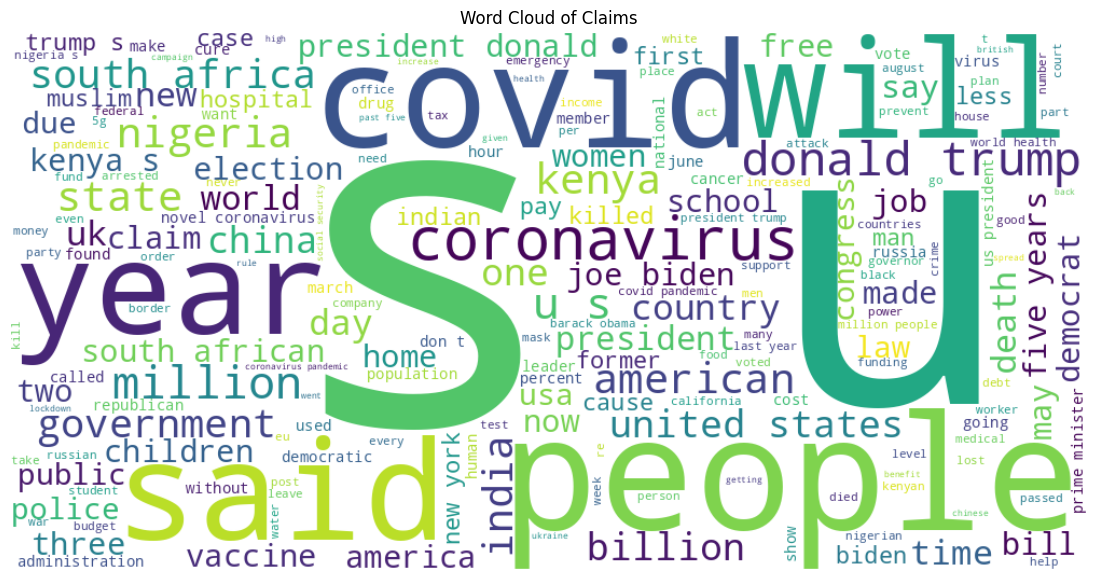

In [15]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Define simple stopwords
custom_stopwords = set([
    'the', 'and', 'to', 'of', 'in', 'that', 'is', 'for', 'on', 'with', 'as',
    'by', 'at', 'from', 'an', 'be', 'this', 'are', 'it', 'was', 'or', 'which',
    'has', 'have', 'a', 'but', 'not', 'they', 'their', 'its', 'who'
])

# Combine all claims
claims_text = " ".join(df["claim"].astype(str).tolist())

# Tokenize using regex
tokens = re.findall(r'\b\w+\b', claims_text.lower())

# Filter stopwords
filtered_tokens = [w for w in tokens if w not in custom_stopwords]
filtered_text = " ".join(filtered_tokens)

# Generate and show word cloud
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(filtered_text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Claims")
plt.show()


In [18]:
import plotly.express as px

# Top 10 reporting sources
top_sources = df["reporting_source"].value_counts().head(10).reset_index()
top_sources.columns = ["reporting_source", "count"]

fig = px.bar(
    top_sources,
    x="count",
    y="reporting_source",
    orientation="h",
    title="Top 10 Reporting Sources of Claims",
    labels={"count": "Number of Claims", "reporting_source": "Reporting Source"}
)
fig.show()


In [19]:
from urllib.parse import urlparse

# Extract domain from URL
df["claim_domain"] = df["original_claim_url"].apply(lambda x: urlparse(x).netloc if pd.notna(x) else "Unknown")

# Top 10 domains
top_domains = df["claim_domain"].value_counts().head(10).reset_index()
top_domains.columns = ["domain", "count"]

fig = px.bar(
    top_domains,
    x="count",
    y="domain",
    orientation="h",
    title="Top Original Claim Domains",
    labels={"count": "Number of Claims", "domain": "Domain"}
)
fig.show()
